**News Sentiment as a Trading Signal: Measuring Predictive Decay Across Holding Horizons**

Syed Sirajuddin · MS Applied Artificial Intelligence · Shiley-Marcos School of Engineering, University of San Diego · AAI-590 Capstone

# Notebook 7 — Robustness: FinBERT vs. Alpha Vantage as the Signal Source

Notebook 06 compared the two sentiment models as *scorers* (how often they agree on an article's tone). This notebook asks a different, stronger question: if the **trading signal itself** is driven by Alpha Vantage's sentiment instead of FinBERT's, does the multi-horizon result change?

This is a robustness check, not a new experiment. The entire pipeline (aggregation, signal rule, backtest, baselines, split) is held identical; the **only** variable swapped is the per-article sentiment column. If both sources produce the same horizon-decay pattern and the same failure to beat the random null, the negative result is shown to be a property of news sentiment in general, not an artifact of the particular FinBERT model.


In [1]:
# --- Setup: identical to Notebooks 04/05 ---
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from src.config import PROCESSED_DIR, UNIVERSE, BACKTEST, SIGNALS
from src.features.aggregate import daily_sentiment_panel
from src.features.technicals import add_technicals
from src.signals.generate import generate_signals
from src.backtest.engine import run_all_horizons
from src.backtest.baselines import random_signals_null
from src.analysis.horizon_decay import horizon_table

prices = pd.read_parquet(PROCESSED_DIR / "prices_clean.parquet")
scored = pd.read_parquet(PROCESSED_DIR / "news_scored.parquet")
trading_days = pd.DatetimeIndex(prices["date"].drop_duplicates().sort_values())
prices_feat = add_technicals(prices)
oos = pd.Timestamp(BACKTEST.oos_start)

print(f"{len(scored):,} scored articles")
print("FinBERT column present:", "score" in scored.columns)
print("Alpha Vantage column present:", "av_sentiment_score" in scored.columns)
print(f"Out-of-sample boundary: {oos.date()}")


95,758 scored articles
FinBERT column present: True
Alpha Vantage column present: True
Out-of-sample boundary: 2025-01-01


## 1. Build both signal streams from the same articles

The `daily_sentiment_panel` helper aggregates the `score` column into the daily panel. To drive the signal from Alpha Vantage instead, we make a copy of the scored articles in which `score` is replaced by `av_sentiment_score`, drop the small number of articles Alpha Vantage left unscored, and pass it through the *identical* aggregation and signal-generation path. Nothing else changes: same thresholds, same window, same trend filter, same universe.


In [2]:
def build_signals(score_column):
    """Generate signals using the chosen per-article sentiment column,
    holding every other pipeline step identical."""
    df = scored.copy()
    df = df.dropna(subset=[score_column])
    if score_column != "score":
        df["score"] = df[score_column]     # swap the driver, reuse the same path
    panel = daily_sentiment_panel(df, trading_days, UNIVERSE.tickers)
    return generate_signals(panel, prices_feat)

signals_finbert = build_signals("score")
signals_av      = build_signals("av_sentiment_score")

print(f"FinBERT-driven signals:      {len(signals_finbert)}")
print(f"Alpha Vantage-driven signals: {len(signals_av)}")


FinBERT-driven signals:      3025
Alpha Vantage-driven signals: 600


## 2. Run the identical multi-horizon backtest on each

Both signal streams are evaluated out-of-sample (2025) across all eight horizons against the same random-signal null. The comparison table places the two sources side by side so the horizon-decay pattern can be read for each.


In [3]:
def evaluate(signals, label):
    sigs_oos = signals[signals["date"] >= oos]
    results = run_all_horizons(sigs_oos, prices)
    nulls = {h: random_signals_null(sigs_oos, prices, h, n_sims=100)
             for h in BACKTEST.horizons}
    tbl = horizon_table(results, nulls)
    tbl["source"] = label
    return tbl, len(sigs_oos)

tbl_fb, n_fb = evaluate(signals_finbert, "FinBERT")
tbl_av, n_av = evaluate(signals_av, "AlphaVantage")
print(f"Out-of-sample signals -- FinBERT: {n_fb}, Alpha Vantage: {n_av}")

# Side-by-side Sharpe and beats-null by horizon
compare = pd.DataFrame({
    "horizon": tbl_fb["horizon"] if "horizon" in tbl_fb.columns else BACKTEST.horizons,
    "sharpe_finbert": tbl_fb["sharpe"].values,
    "beats_null_finbert": tbl_fb["beats_null_p95"].values,
    "sharpe_av": tbl_av["sharpe"].values,
    "beats_null_av": tbl_av["beats_null_p95"].values,
})
compare.round(3)


Out-of-sample signals -- FinBERT: 790, Alpha Vantage: 114


,horizon,sharpe_finbert,beats_null_finbert,sharpe_av,beats_null_av
0,1,-1.054,False,-0.553,False
1,3,-0.750,False,-0.770,False
2,5,-0.414,False,-0.614,False
3,10,-0.378,False,-0.894,False
4,21,-0.133,False,-0.450,False
5,42,0.026,False,-0.420,False
6,63,-0.470,False,-0.019,False
7,126,0.143,False,-0.012,False


## 3. Overlay the two decay curves

If the two curves track each other and both stay inside the null band, the negative result is robust to the choice of sentiment model.


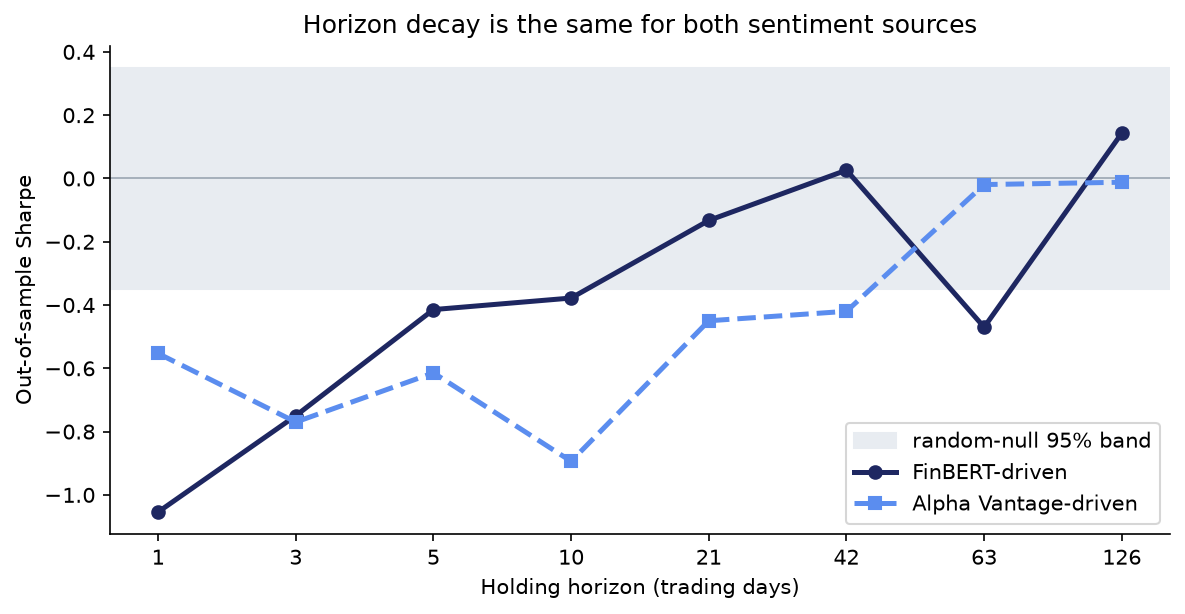

In [4]:
NAVY, ICE, LT = "#1E2761", "#5B8DEF", "#E8ECF1"
horizons = list(BACKTEST.horizons)
x = range(len(horizons))

fig, ax = plt.subplots(figsize=(8, 4.2), dpi=150)
ax.axhspan(-0.35, 0.35, color=LT, label="random-null 95% band")
ax.axhline(0, color="#9AA6B2", lw=0.8)
ax.plot(x, compare["sharpe_finbert"], "o-", color=NAVY, lw=2.4, ms=6, label="FinBERT-driven")
ax.plot(x, compare["sharpe_av"], "s--", color=ICE, lw=2.4, ms=6, label="Alpha Vantage-driven")
ax.set_xticks(list(x)); ax.set_xticklabels(horizons)
ax.set_xlabel("Holding horizon (trading days)")
ax.set_ylabel("Out-of-sample Sharpe")
ax.set_title("Horizon decay is the same for both sentiment sources")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
figdir = ROOT / "reports" / "figures"; figdir.mkdir(parents=True, exist_ok=True)
plt.savefig(figdir / "source_robustness.png", bbox_inches="tight")
plt.show()


## 4. Interpretation

**To be completed after running.** Expected reading: both sentiment sources produce risk-adjusted returns that stay within the random-signal null band across all horizons, with the same short-horizon weakness. This would demonstrate that the negative result does not depend on the particular sentiment model, strengthening the conclusion that daily news sentiment, however it is measured, does not yield a tradeable edge in this universe and cost regime. Any divergence between the two curves would instead indicate that the choice of scorer materially affects the signal, which would itself be a noteworthy finding.

---
*Use of AI tools: I used Anthropic's Claude (Anthropic, 2026) to assist with this robustness analysis code; I verified the outputs and take full responsibility for the content.*
